In [1]:
# NOTE: unfortunately depends_on_optional machinery in a submodule prevents autoreload from working for that submodule
%load_ext autoreload
%autoreload 2

In [2]:
#import pyproj
#pyproj_dir = '/home/sbhusha1/.conda/envs/coincident/lib/python3.13/site-packages/pyproj/proj_dir/share/proj'

#pyproj.datadir.set_data_dir(pyproj_dir)

import common_functions
import os
import pandas as pd
# TODO: consider moving some pieces into coincident library
import cql2
import numpy as np
from rasterstats import point_query, zonal_stats
from affine import Affine
import pyproj
import rasterio
import xarray as xr
from osgeo import gdal
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt
import sliderule
import coincident
from coincident import pcd_fixtures
from sliderule import earthdata, icesat2, gedi

/panfs/ccds02/nobackup/people/sbhusha1/sw/coincident/src/coincident/io/download.py:28: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/panfs/ccds02/nobackup/people/sbhusha1/sw/coincident/src/coincident/search/main.py:15: UserWarning: Unable to authenticate with Maxar API. Please set MAXAR_API_KEY environment variable.
  from coincident.search import neon_api, opentopo_api, stac, wesm


In [3]:
%cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_first_product_delivery_sep17_25/neon_pcd_products/

/panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_first_product_delivery_sep17_25/neon_pcd_products


In [4]:
gedi_column='elevation_98_perc'
gedi_name = "GEDI (98 perc)"

In [5]:
## Functions
def load_stv_product_local(href, overview_level=None):
    if overview_level is not None:
        da = xr.open_dataarray(
            href,
            engine="rasterio",
            mask_and_scale=True,
            backend_kwargs={"open_kwargs": {"overview_level": overview_level}},
        ).squeeze()
    else:
        da = xr.open_dataarray(
            href,
            engine="rasterio",
            mask_and_scale=True,
        ).squeeze()
    return da

def compute_gedi_surface(row):
    rh_array = np.fromstring(row['rh'].strip('[]'), sep=' ')
    output = row['elevation_lm']+rh_array[-1]
    return output

def compute_gedi_surface(row):
    rh_array = np.fromstring(row['rh'].strip('[]'), sep=' ')
    output = row['elevation_lm']+rh_array[-1]
    return output

In [6]:
gf_is2_stac = gpd.read_file('/home/sbhusha1/notebooks/pcd/20250718_PCD_neon_is2_tracks.geojson')
workunits = np.unique(gf_is2_stac.neon_id)

In [7]:
lidar_dtm_fn = 'BART_processing/BART-DTM_fill_window_size_4_mos.tif'
lidar_dsm_fn = 'BART_processing/BART-DSM_mos.tif'
stereo_dsm_fn = 'BART_processing/stereo_DEM_mos.tif'
#is2_gdf_fn = ''
gedi_gdf_fn = '../../neon/delivery_version2/BART_processing/GEDI_aligned_product_BART.gpkg'
cop30_fn = 'BART_processing/COP30_E.tif'

In [8]:
workunit = workunits[0]

In [9]:
OVR = None
    

lidar_dtm_da = load_stv_product_local(lidar_dtm_fn, overview_level=OVR)
lidar_dtm_da.name = "DTM"

lidar_dsm_da = load_stv_product_local(lidar_dsm_fn, overview_level=OVR)
lidar_dsm_da.name = "DSM"

stereo_dsm_da = load_stv_product_local(stereo_dsm_fn,overview_level=OVR)
stereo_dsm_da_reproj = stereo_dsm_da.rio.reproject_match(
    lidar_dsm_da,
    resampling="bilinear",
)
if cop30_fn is not None:
    cop30_da = load_stv_product_local(cop30_fn)
    cop30_da_reproj = cop30_da.rio.reproject_match(
        lidar_dsm_da,
        resampling='bilinear',
    )
## read geodataframe & reproject
gedi_gdf = gpd.read_file(gedi_gdf_fn)
gedi_gdf_reproj = gedi_gdf.to_crs(stereo_dsm_da.rio.crs)
gedi_gdf_reproj[gedi_column] = gedi_gdf_reproj.apply(compute_gedi_surface,axis=1)
gedi_gdf_reproj

## use sliderule to query IS-2

#is2_ids = [str(value)+'.h5' for value in gf_is2_stac.tail(3).is2_granule_id.values.tolist()]
mask = gf_is2_stac['neon_id'] == workunit
    
is2_ids = [str(value)+'.h5' for value in gf_is2_stac[mask].is2_granule_id.values.tolist()]
print(is2_ids)
datetime = [str(np.sort(gf_is2_stac[mask].date.values)[0]), str(np.sort(gf_is2_stac[mask].date.values)[-1])]
da_bounds = lidar_dsm_da.rio.bounds()  # (minx, miny, maxx, maxy)
da_box = box(*da_bounds)
gf_search = gpd.GeoDataFrame(geometry=[da_box],
                             columns=['geometry'],
                             crs = lidar_dsm_da.rio.crs)
gf_search = gf_search.to_crs(4326)

poly_sliderule = sliderule.toregion(gf_search)['poly']
#https://nbviewer.org/github/ICESat2-SlideRule/sliderule-python/blob/main/examples/phoreal.ipynb
parms = {
    "poly": poly_sliderule,
    "t0": datetime[0],
    "t1": datetime[1],
}

gf_is2 = icesat2.atl06p(parms,
                        resources=is2_ids)

gf_is2_reproj = gf_is2.to_crs(lidar_dsm_da.rio.crs)




['ATL03_20190903043904_10250402_006_02.h5', 'ATL03_20190807181029_06210406_006_02.h5']


In [10]:
## prepare for plotting
if cop30_fn is not None:
    dems = {
    "3DEP DSM": lidar_dsm_da,
    "COP30 DSM": cop30_da_reproj,
    "Stereo DSM": stereo_dsm_da_reproj,
    
    #"PCD Stereo DEM 1m": da_stereo_crop,
    }
else:
    dems = {
    "3DEP DSM": lidar_dsm_da,
    "Stereo DSM": stereo_dsm_da_reproj
    }


# altimeters = {"IS2 (h_li)": (data_is2_r_crop , "h_li"), "GEDI (lm)": (data_gedi_r_crop, "elevation_lm")}
altimeters = {
"IS2 (h_mean)": (gf_is2_reproj, "h_mean"),
f"GEDI": (gedi_gdf_reproj, gedi_column),
}

In [11]:
gdf_dict = altimeters

In [11]:
for _, (key, (gdf, column)) in enumerate(gdf_dict.items() if gdf_dict else []):
    print(key)

IS2 (h_mean)
GEDI


In [12]:
def da_to_rasterstats_inputs(da):
    """
    Extract numpy array, affine transform, and nodata
    from an xarray DataArray for use with rasterstats.

    Parameters
    ----------
    da : xarray.DataArray
        2D array with dimensions (y, x).

    Returns
    -------
    data : np.ndarray
    affine : Affine
    nodata : float or None
    """
    data = da.values

    x = da.x.values
    y = da.y.values
    res_x = float(x[1] - x[0])
    res_y = float(y[1] - y[0])  # typically negative for top-down rasters

    # Affine: upper-left corner of the upper-left pixel
    affine = Affine(res_x, 0, x[0] - res_x / 2,
                    0, res_y, y[0] - res_y / 2)

    nodata = None
    if hasattr(da, "rio") and da.rio.nodata is not None:
        nodata = da.rio.nodata
    elif "_FillValue" in da.attrs:
        nodata = da.attrs["_FillValue"]
    elif "_FillValue" in da.encoding:
        nodata = da.encoding["_FillValue"]

    return data, affine, nodata



def sample_windowed_stats(da, gdf, window_radius=12.5,
                          stats=["mean", "median", "std", "min", "max", "count"]):
    """
    Zonal statistics within a circular buffer around each point
    to mimic GEDI footprint.

    Parameters
    ----------
    da : xarray.DataArray
    gdf : GeoDataFrame
    window_radius : float
        Radius in same units as da coordinates (e.g., 12.5 m for 25 m diameter GEDI footprint).
    stats : list of str
        rasterstats stat names.

    Returns
    -------
    dict of np.ndarrays
    """
    data, affine, nodata = da_to_rasterstats_inputs(da)

    gdf_buf = gdf.copy()
    gdf_buf["geometry"] = gdf_buf.geometry.buffer(window_radius)  # circular by default

    zs = zonal_stats(
        gdf_buf,
        data,
        affine=affine,
        nodata=nodata,
        stats=stats,
    )

    return {s: np.array([z[s] for z in zs], dtype=float) for s in stats}

In [13]:
def da_to_rasterstats_inputs(da):
    """
    Extract numpy array, affine transform, and nodata
    from an xarray DataArray for use with rasterstats.

    Parameters
    ----------
    da : xarray.DataArray
        2D array with dimensions (y, x).

    Returns
    -------
    data : np.ndarray
    affine : Affine
    nodata : float or None
    """
    data = da.values

    x = da.x.values
    y = da.y.values
    res_x = float(x[1] - x[0])
    res_y = float(y[1] - y[0])  # typically negative for top-down rasters

    # Affine: upper-left corner of the upper-left pixel
    affine = Affine(res_x, 0, x[0] - res_x / 2,
                    0, res_y, y[0] - res_y / 2)

    nodata = None
    if hasattr(da, "rio") and da.rio.nodata is not None:
        nodata = da.rio.nodata
    elif "_FillValue" in da.attrs:
        nodata = da.attrs["_FillValue"]
    elif "_FillValue" in da.encoding:
        nodata = da.encoding["_FillValue"]

    return data, affine, nodata



def sample_windowed_stats(da, gdf, window_radius=12.5,
                          stats=["mean", "median", "std", "min", "max", "count"]):
    """
    Zonal statistics within a circular buffer around each point
    to mimic GEDI footprint.

    Parameters
    ----------
    da : xarray.DataArray
    gdf : GeoDataFrame
    window_radius : float
        Radius in same units as da coordinates (e.g., 12.5 m for 25 m diameter GEDI footprint).
    stats : list of str
        rasterstats stat names.

    Returns
    -------
    dict of np.ndarrays
    """
    data, affine, nodata = da_to_rasterstats_inputs(da)

    gdf_buf = gdf.copy()
    gdf_buf["geometry"] = gdf_buf.geometry.buffer(window_radius)  # circular by default

    zs = zonal_stats(
        gdf_buf,
        data,
        affine=affine,
        nodata=nodata,
        stats=stats,
    )

    return {s: np.array([z[s] for z in zs], dtype=float) for s in stats}

def sample_dem_at_points(
    da_dem: xr.DataArray,
    gdf_points: gpd.GeoDataFrame,
    sampling_method: str = 'bilinear',
    diff_col: str | None = None,
) -> pd.DataFrame:
    """
    Sample DEM at point locations from GeoDataFrame using Xarray Advanced Interpolation (bilinear interpolation)
    If the GeoDataFrame column name is provided (e.g. h_li for IS2 ATL06), also calculate
    difference by subtracting the sampled raster elevation.

    Parameters
    ----------
    da_dem: xr.DataArray
        DEM as xarray DataArray with only 'x' and 'y' spatial dimensions
    gdf_points: gpd.GeoDataFrame
        GeoDataFrame with point geometries to sample DEM at
    sample_method: str
        sampling method, defaualt is bilinear interpolation. If max or median, will give maximum return within a 25 m footprint (mimicing GEDI). Max should be used for canopy, comparison, while median for ground measurements.
    diff_col: Optional[str]
        Column in GeoDataFrame to difference [gdf_points[diff_col] - DEM]

    Returns
    -------
    gpd.pd.GeoDataFrame
        GeoDataFrame with sampled DEM elevations and optional 'elev_diff' column
    """
    assert isinstance(da_dem, xr.DataArray), "da_dem must be an xarray.DataArray"
    da_points = gdf_points.get_coordinates().to_xarray()
    # Ensure we don't return a multi-index
    da_dem = da_dem.squeeze()
    if sampling_method == 'bilinear':
        samples = (
            da_dem.drop_vars(["band", "spatial_ref"])
            .interp(da_points)
            .to_dataframe(name="dem_elevation")
        )
    else:
        output = sample_windowed_stats(da_dem,gdf_points,window_radius=12.5,stats=[sampling_method])[sampling_method]
        samples = gdf_points.get_coordinates()
        samples['dem_elevation'] = output
    if diff_col is not None:
        samples[diff_col] = gdf_points[diff_col].to_numpy()
        samples["elev_diff"] = (
            gdf_points[diff_col].to_numpy() - samples["dem_elevation"]
        )

    return samples

In [14]:
gedi_gdf_reproj.get_coordinates()

,x,y
0,317445.284851,4.878217e+06
1,317492.677860,4.878185e+06
2,317539.751155,4.878154e+06
3,317587.658098,4.878122e+06
4,317635.290573,4.878090e+06
...,...,...
1282,323439.496563,4.876048e+06
1283,323488.359194,4.876076e+06
1284,323537.388478,4.876105e+06
1285,323586.184336,4.876133e+06


In [15]:
output = sample_dem_at_points(lidar_dsm_da,gedi_gdf_reproj,sampling_method='bilinear',diff_col='elevation_98_perc')

In [16]:
output

,x,y,dem_elevation,elevation_98_perc,elev_diff
index,,,,,
0,317445.284851,4.878217e+06,483.837843,491.547185,7.709342
1,317492.677860,4.878185e+06,497.064401,507.676194,10.611793
2,317539.751155,4.878154e+06,514.155430,522.094816,7.939386
3,317587.658098,4.878122e+06,516.999115,524.841403,7.842287
4,317635.290573,4.878090e+06,513.699608,520.878346,7.178738
...,...,...,...,...,...
1282,323439.496563,4.876048e+06,NaN,705.679436,NaN
1283,323488.359194,4.876076e+06,NaN,714.977463,NaN
1284,323537.388478,4.876105e+06,NaN,724.711091,NaN


In [17]:
output.describe()

,x,y,dem_elevation,elevation_98_perc,elev_diff
count,1287.000000,1.287000e+03,1127.000000,1287.000000,1127.000000
mean,319988.182088,4.875065e+06,420.195159,432.887748,8.038627
std,2171.595927,1.432620e+03,136.521502,138.269996,4.372644
min,315694.382324,4.872837e+06,205.850190,209.101957,-22.145620
25%,318269.566009,4.873879e+06,318.933894,325.191524,5.171365
50%,320051.237888,4.874905e+06,391.148603,405.697311,7.189575
75%,321828.471488,4.876112e+06,503.288035,527.338997,9.964958
max,323642.416340,4.878223e+06,926.341452,934.249834,31.204520


In [19]:
max_sample_output = sample_dem_at_points(lidar_dsm_da,gedi_gdf_reproj,sampling_method='max',diff_col='elevation_98_perc') 

In [ ]:
output.head(30)

In [ ]:
max_sample_output.head(30)

In [21]:
import scipy

In [25]:
val_array = output['elev_diff'].values
val_array = val_array[~np.isnan(val_array)]
med = np.median(val_array)
nmad = scipy.stats.median_abs_deviation(val_array)*1.4826

In [26]:
nmad

np.float64(3.3410611550450025)

In [28]:
med

np.float64(7.189575217692436)

In [ ]:
def da_to_rasterstats_inputs(da):
    """
    Extract numpy array, affine transform, and nodata
    from an xarray DataArray for use with rasterstats.

    Parameters
    ----------
    da : xarray.DataArray
        2D array with dimensions (y, x).

    Returns
    -------
    data : np.ndarray
    affine : Affine
    nodata : float or None
    """
    data = da.values

    x = da.x.values
    y = da.y.values
    res_x = float(x[1] - x[0])
    res_y = float(y[1] - y[0])  # typically negative for top-down rasters

    # Affine: upper-left corner of the upper-left pixel
    affine = Affine(res_x, 0, x[0] - res_x / 2,
                    0, res_y, y[0] - res_y / 2)

    nodata = None
    if hasattr(da, "rio") and da.rio.nodata is not None:
        nodata = da.rio.nodata
    elif "_FillValue" in da.attrs:
        nodata = da.attrs["_FillValue"]
    elif "_FillValue" in da.encoding:
        nodata = da.encoding["_FillValue"]

    return data, affine, nodata



def sample_windowed_stats(da, gdf, window_radius=12.5,
                          stats=["mean", "median", "std", "min", "max", "count"]):
    """
    Zonal statistics within a circular buffer around each point
    to mimic GEDI footprint.

    Parameters
    ----------
    da : xarray.DataArray
    gdf : GeoDataFrame
    window_radius : float
        Radius in same units as da coordinates (e.g., 12.5 m for 25 m diameter GEDI footprint).
    stats : list of str
        rasterstats stat names.

    Returns
    -------
    dict of np.ndarrays
    """
    data, affine, nodata = da_to_rasterstats_inputs(da)

    gdf_buf = gdf.copy()
    gdf_buf["geometry"] = gdf_buf.geometry.buffer(window_radius)  # circular by default

    zs = zonal_stats(
        gdf_buf,
        data,
        affine=affine,
        nodata=nodata,
        stats=stats,
    )

    return {s: np.array([z[s] for z in zs], dtype=float) for s in stats}

def sample_dem_at_points(
    da_dem: xr.DataArray,
    gdf_points: gpd.GeoDataFrame,
    sampling_method: str = 'bilinear',
    diff_col: str | None = None,
) -> pd.DataFrame:
    """
    Sample DEM at point locations from GeoDataFrame using Xarray Advanced Interpolation (bilinear interpolation)
    If the GeoDataFrame column name is provided (e.g. h_li for IS2 ATL06), also calculate
    difference by subtracting the sampled raster elevation.

    Parameters
    ----------
    da_dem: xr.DataArray
        DEM as xarray DataArray with only 'x' and 'y' spatial dimensions
    gdf_points: gpd.GeoDataFrame
        GeoDataFrame with point geometries to sample DEM at
    sample_method: str
        sampling method, defaualt is bilinear interpolation. If max or median, will give maximum return within a 25 m footprint (mimicing GEDI). Max should be used for canopy, comparison, while median for ground measurements.
    diff_col: Optional[str]
        Column in GeoDataFrame to difference [gdf_points[diff_col] - DEM]

    Returns
    -------
    gpd.pd.GeoDataFrame
        GeoDataFrame with sampled DEM elevations and optional 'elev_diff' column
    """
    assert isinstance(da_dem, xr.DataArray), "da_dem must be an xarray.DataArray"
    da_points = gdf_points.get_coordinates().to_xarray()
    # Ensure we don't return a multi-index
    da_dem = da_dem.squeeze()
    if sampling_method == 'bilinear':
        samples = (
            da_dem.drop_vars(["band", "spatial_ref"])
            .interp(da_points)
            .to_dataframe(name="dem_elevation")
        )
    else:
        output = sample_windowed_stats(da_dem,gdf_points,window_radius=12.5,stats=[sampling_method])[sampling_method]
        samples = gdf_points.get_coordinates()
        samples['dem_elevation'] = output
    if diff_col is not None:
        samples[diff_col] = gdf_points[diff_col].to_numpy()
        samples["elev_diff"] = (
            gdf_points[diff_col].to_numpy() - samples["dem_elevation"]
        )

    return samples

Text(0.5, 1.0, 'GEDI footprint RH-100 vs ALS DSM bilinear at exact GEDI point location\nMED: 7.19m, NMAD: 3.34m')

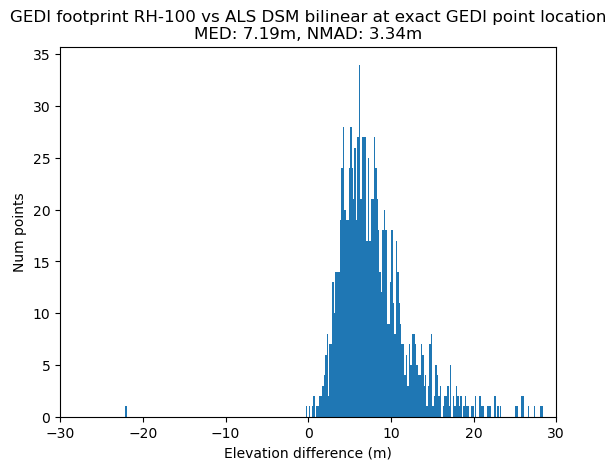

In [29]:
f,ax = plt.subplots()

ax.hist(output['elev_diff'],bins=300)
ax.set_xlim(-30,30)
ax.set_xlabel('Elevation difference (m)')
ax.set_ylabel('Num points')
title_stats = f"\nMED: {med:.2f}m, NMAD: {nmad:.2f}m"
ax.set_title('GEDI footprint RH-100 vs ALS DSM bilinear at exact GEDI point location'+title_stats)

In [30]:
val_array = max_sample_output['elev_diff'].values
val_array = val_array[~np.isnan(val_array)]
med = np.median(val_array)
nmad = scipy.stats.median_abs_deviation(val_array)*1.4826

Text(0.5, 1.0, 'GEDI footprint RH-100 vs zonal stats max of ALS DSM within 25 m GEDI footprint\nMED: 0.40m, NMAD: 1.61m')

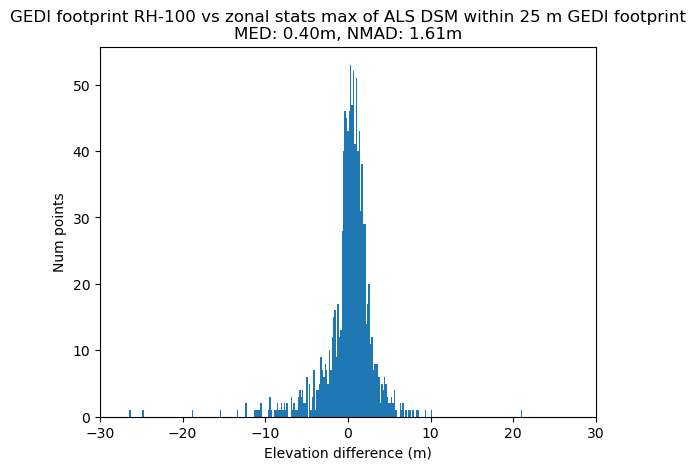

In [31]:
f,ax = plt.subplots()

ax.hist(max_sample_output['elev_diff'],bins=3000)
ax.set_xlim(-30,30)
ax.set_xlim(-30,30)
ax.set_xlabel('Elevation difference (m)')
ax.set_ylabel('Num points')
title_stats = f"\nMED: {med:.2f}m, NMAD: {nmad:.2f}m"
ax.set_title('GEDI footprint RH-100 vs zonal stats max of ALS DSM within 25 m GEDI footprint'+title_stats)

In [17]:
data, affine, nodata = da_to_rasterstats_inputs(lidar_dsm_da)

In [19]:
nodata

np.float32(nan)

In [21]:
gdf_buf = gedi_gdf_reproj.copy()
gdf_buf["geometry"] = gdf_buf.geometry.buffer(12.5)  # circular by default

In [23]:
gdf_buf

,time,solar_elevation,sensitivity,flags,orbit,beam,track,elevation_hr,rh,master_frac,energy_total,quality_flag,elevation_lm,easting,northing,geometry,elevation_98_perc
0,2019-07-14 09:04:46.591,-2.593858,0.993359,130,3315,8,5405,491.858612,[-6.810e+00 -4.560e+00 -2.880e+00 -1.680e+00 -...,0.591643,19626.919922,1,458.927185,317445.284851,4.878217e+06,"POLYGON ((317457.785 4878216.705, 317457.725 4...",483.117185
1,2019-07-14 09:04:46.599,-2.593631,0.991646,130,3315,8,5405,507.991180,[-4.64 -2.39 -0.93 0.11 1.19 2.28 3.29 4....,0.599907,17553.208984,1,473.786194,317492.677860,4.878185e+06,"POLYGON ((317505.178 4878185.126, 317505.118 4...",501.236194
2,2019-07-14 09:04:46.608,-2.593402,0.989889,130,3315,8,5405,522.405457,[-14.34 -12.24 -11.16 -10.26 -9.43 -8.72 -8...,0.608171,19337.328125,1,506.404816,317539.751155,4.878154e+06,"POLYGON ((317552.251 4878153.664, 317552.191 4...",516.884816
3,2019-07-14 09:04:46.616,-2.593173,0.994420,130,3315,8,5405,525.151001,[-7.37 -4.6 -1.57 0.18 1.83 3.18 4.23 5....,0.616435,20440.798828,1,492.781403,317587.658098,4.878122e+06,"POLYGON ((317600.158 4878121.89, 317600.098 48...",519.071403
4,2019-07-14 09:04:46.624,-2.592943,0.993563,130,3315,8,5405,521.186768,[-8.31 -5.43 -3.48 -1.49 0.03 1.38 2.43 3....,0.624699,22778.888672,1,494.398346,317635.290573,4.878090e+06,"POLYGON ((317647.791 4878090.216, 317647.73 48...",515.478346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1282,2019-07-29 21:30:54.727,27.305931,0.964048,130,3556,0,995,705.989929,[-7.33 -6.7 -6.28 -5.91 -5.57 -5.2 -4.9 -4....,0.727761,6344.726562,1,698.609436,323439.496563,4.876048e+06,"POLYGON ((323451.997 4876047.632, 323451.936 4...",703.019436
1283,2019-07-29 21:30:54.736,27.305473,0.933016,130,3556,0,995,715.292847,[-6.81 -6.43 -6.1 -5.8 -5.53 -5.31 -5.09 -4....,0.736025,6810.673340,1,707.837463,323488.359194,4.876076e+06,"POLYGON ((323500.859 4876076.174, 323500.799 4...",711.727463
1284,2019-07-29 21:30:54.744,27.305017,0.954341,130,3556,0,995,725.025269,[-3.03 -2.43 -1.94 -1.53 -1.16 -0.82 -0.59 -0....,0.744289,6066.284668,1,711.431091,323537.388478,4.876105e+06,"POLYGON ((323549.888 4876104.885, 323549.828 4...",721.681091
1285,2019-07-29 21:30:54.752,27.304564,0.959637,130,3556,0,995,737.434326,[-5.31 -4.71 -4.22 -3.74 -3.14 -2.58 -2.02 -1....,0.752553,5651.270508,1,723.016724,323586.184336,4.876133e+06,"POLYGON ((323598.684 4876133.355, 323598.624 4...",734.276724


In [27]:
stats = ['max']
zs = zonal_stats(
    gdf_buf,
    data,
    affine=affine,
    nodata=nodata,
    stats=stats,
)

In [32]:
l = {s: np.array([z[s] for z in zs], dtype=float) for s in stats}

In [34]:
type(l)

dict

In [35]:
l['max']

array([488.28762817, 505.97463989, 521.92285156, ...,          nan,
                nan,          nan], shape=(1287,))

### Check Median height of ground return before and after geolocation correction

In [32]:
%cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_first_product_delivery_sep17_25/usgs_pcd_products/

/panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_first_product_delivery_sep17_25/usgs_pcd_products


In [33]:
lidar_dtm_fn = 'TX_DesertMountains_B1_2018_processing/TX_DesertMountains_B1_2018-DTM_fill_window_size_4_mos.tif'
#lidar_dsm_fn = 'BART_processing/BART-DSM_mos.tif'
#stereo_dsm_fn = 'BART_processing/stereo_DEM_mos.tif'
#is2_gdf_fn = ''
gedi_gdf_fn = '/panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_usgs_lpc_proc_total_bounds/delivery_version2/TX_DesertMountains_B1_2018_processing_98_percentile/GEDI_aligned_product_TX_DesertMountains_B1_2018.gpkg'


In [34]:
lidar_dtm_da = load_stv_product_local(lidar_dtm_fn)

In [35]:
gedi_gdf = gpd.read_file(gedi_gdf_fn)
gedi_gdf_reproj = gedi_gdf.to_crs(lidar_dtm_da.rio.crs)
gedi_gdf_reproj[gedi_column] = gedi_gdf_reproj.apply(compute_gedi_surface,axis=1)
gedi_gdf_reproj

,beam,orbit,sensitivity,solar_elevation,flags,track,elevation_hr,rh,master_frac,energy_total,quality_flag,elevation_lm,easting,northing,geometry,elevation_98_perc
0,2,4279,0.905411,-9.196758,130,4122,1528.019287,[-3.18 -2.95 -2.73 -2.58 -2.43 -2.32 -2.2 -2....,0.142923,3272.776855,1,1524.302734,431905.505774,3.489582e+06,POINT (431905.506 3489581.801),1527.782734
1,2,4279,0.902510,-9.196123,130,4122,1527.302734,[-3.33 -3.1 -2.88 -2.73 -2.58 -2.43 -2.32 -2....,0.159451,3175.403564,1,1523.810913,431984.782686,3.489500e+06,POINT (431984.783 3489499.783),1527.060913
2,2,4279,0.905578,-9.195156,130,4122,1526.458008,[-3.18 -2.95 -2.77 -2.62 -2.47 -2.35 -2.24 -2....,0.184243,3278.558594,1,1522.778809,432103.704443,3.489377e+06,POINT (432103.704 3489376.741),1526.218809
3,2,4279,0.904305,-9.194515,130,4122,1525.863403,[-3.44 -3.22 -2.99 -2.8 -2.65 -2.54 -2.39 -2....,0.200771,3234.954834,1,1522.221802,432182.981622,3.489295e+06,POINT (432182.982 3489294.7),1525.621802
4,2,4279,0.911180,-9.194194,130,4122,1525.320068,[-3.4 -3.14 -2.92 -2.77 -2.62 -2.47 -2.35 -2....,0.209035,3852.230957,1,1521.977905,432222.619410,3.489254e+06,POINT (432222.619 3489253.675),1525.077905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5806,8,5042,0.954353,34.311985,130,1429,1525.760010,[-4.11 -3.59 -3.22 -2.95 -2.77 -2.58 -2.43 -2....,0.311596,11422.007812,1,1521.907593,439305.468477,3.483984e+06,POINT (439305.468 3483983.682),1525.457593
5807,11,5042,0.966277,34.316204,130,1429,1537.801880,[-4.08 -3.52 -3.14 -2.88 -2.69 -2.5 -2.39 -2....,0.315728,13045.019531,1,1534.024414,439165.721388,3.483281e+06,POINT (439165.721 3483281.271),1537.504414
5808,11,5042,0.961199,34.316734,130,1429,1538.033813,[-4.11 -3.55 -3.18 -2.92 -2.69 -2.54 -2.39 -2....,0.323992,12177.356445,1,1534.331177,439205.335245,3.483240e+06,POINT (439205.335 3483240.24),1537.731177
5809,11,5042,0.955842,34.317261,130,1429,1538.734253,[-4.11 -3.55 -3.18 -2.92 -2.73 -2.54 -2.39 -2....,0.332256,11069.193359,1,1535.143921,439244.939516,3.483199e+06,POINT (439244.94 3483199.22),1538.433921


In [37]:
output_bilinear_ground = sample_dem_at_points(lidar_dtm_da,gedi_gdf_reproj,sampling_method='bilinear',diff_col='elevation_lm')

In [38]:
output_bilinear_ground.head()

,x,y,dem_elevation,elevation_lm,elev_diff
index,,,,,
0,431905.505774,3.489582e+06,1524.185349,1524.302734,0.117385
1,431984.782686,3.489500e+06,1523.682429,1523.810913,0.128484
2,432103.704443,3.489377e+06,1522.608565,1522.778809,0.170243
3,432182.981622,3.489295e+06,1522.172173,1522.221802,0.049629
4,432222.619410,3.489254e+06,1521.848627,1521.977905,0.129278


In [39]:
median_ground_sample_output = sample_dem_at_points(lidar_dtm_da,gedi_gdf_reproj,sampling_method='median',diff_col='elevation_lm') 

In [40]:
median_ground_sample_output.head()

,x,y,dem_elevation,elevation_lm,elev_diff
0,431905.505774,3.489582e+06,1524.186035,1524.302734,0.116699
1,431984.782686,3.489500e+06,1523.672852,1523.810913,0.138062
2,432103.704443,3.489377e+06,1522.631470,1522.778809,0.147339
3,432182.981622,3.489295e+06,1522.143066,1522.221802,0.078735
4,432222.619410,3.489254e+06,1521.860107,1521.977905,0.117798


Text(0.5, 1.0, 'GEDI footprint elevation vs ALS DTM bilinear at exact GEDI point location\nMED: 0.00m, NMAD: 0.21m')

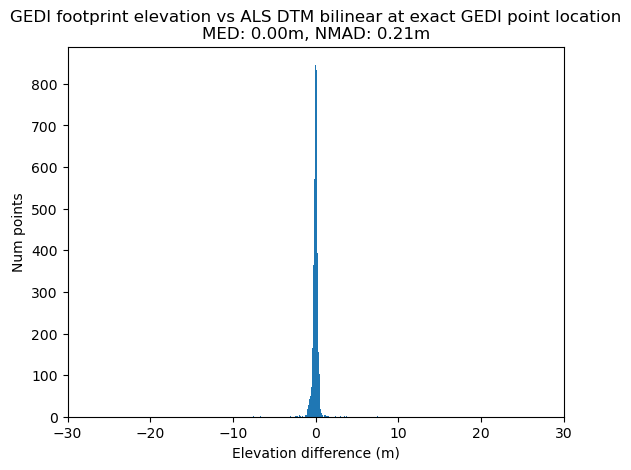

In [41]:
f,ax = plt.subplots()
val_array = output_bilinear_ground['elev_diff'].values
val_array = val_array[~np.isnan(val_array)]
med = np.median(val_array)
nmad = scipy.stats.median_abs_deviation(val_array)*1.4826
ax.hist(val_array,bins=300)
ax.set_xlim(-30,30)
ax.set_xlabel('Elevation difference (m)')
ax.set_ylabel('Num points')
title_stats = f"\nMED: {med:.2f}m, NMAD: {nmad:.2f}m"
ax.set_title('GEDI footprint elevation vs ALS DTM bilinear at exact GEDI point location'+title_stats)

Text(0.5, 1.0, 'GEDI footprint elevation vs ALS DTM median at GEDI footprint\nMED: -0.00m, NMAD: 0.20m')

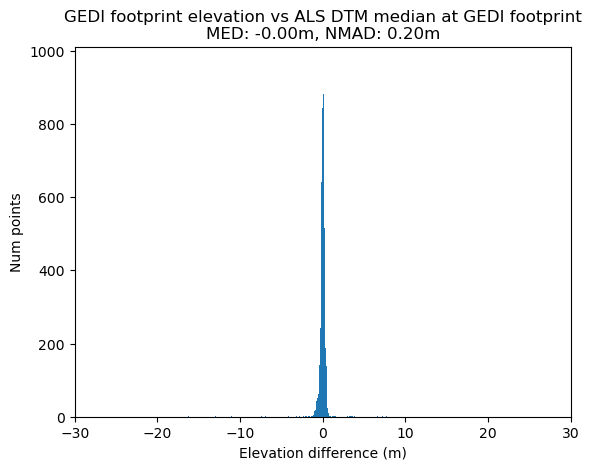

In [42]:
f,ax = plt.subplots()
val_array = median_ground_sample_output['elev_diff'].values
val_array = val_array[~np.isnan(val_array)]
med = np.median(val_array)
nmad = scipy.stats.median_abs_deviation(val_array)*1.4826
ax.hist(val_array,bins=300)
ax.set_xlim(-30,30)
ax.set_xlabel('Elevation difference (m)')
ax.set_ylabel('Num points')
title_stats = f"\nMED: {med:.2f}m, NMAD: {nmad:.2f}m"
ax.set_title('GEDI footprint elevation vs ALS DTM median at GEDI footprint'+title_stats)

## Before Co-reg

In [43]:
ls /panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_usgs_lpc_proc_total_bounds/delivery_version2/TX_DesertMountains_B1_2018_processing_98_percentile/

aligned-diff.csv
alignment_sparse_altimetry_all_TX_DesertMountains_B1_2018_4279_proj/
alignment_sparse_altimetry_all_TX_DesertMountains_B1_2018_4691_proj/
alignment_sparse_altimetry_all_TX_DesertMountains_B1_2018_4915_proj/
alignment_sparse_altimetry_all_TX_DesertMountains_B1_2018_5042_proj/
alignment_sparse_altimetry_all_TX_DesertMountains_B1_2018_proj/
final_proj-diff.csv
GEDI_aligned_product_TX_DesertMountains_B1_2018.gpkg
GEDI_filtered_all_control_points_utm_TX_DesertMountains_B1_2018_4279.csv
GEDI_filtered_all_control_points_utm_TX_DesertMountains_B1_2018_4691.csv
GEDI_filtered_all_control_points_utm_TX_DesertMountains_B1_2018_4915.csv
GEDI_filtered_all_control_points_utm_TX_DesertMountains_B1_2018_5042.csv
GEDI_filtered_all_control_points_utm_TX_DesertMountains_B1_2018_aligned_data.csv
GEDI_filtered_all_control_points_utm_TX_DesertMountains_B1_2018.csv
GEDI_filtered_all_control_points_utm_TX_DesertMountains_B1_2018_original_data.csv
GEDI_original_product_TX_DesertMountains_B1_201

In [44]:
lidar_dtm_fn = 'TX_DesertMountains_B1_2018_processing/TX_DesertMountains_B1_2018-DTM_fill_window_size_4_mos.tif'
#lidar_dsm_fn = 'BART_processing/BART-DSM_mos.tif'
#stereo_dsm_fn = 'BART_processing/stereo_DEM_mos.tif'
#is2_gdf_fn = ''
gedi_gdf_fn = '/panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_usgs_lpc_proc_total_bounds/delivery_version2/TX_DesertMountains_B1_2018_processing_98_percentile/GEDI_original_product_TX_DesertMountains_B1_2018.gpkg'

In [45]:
gedi_gdf = gpd.read_file(gedi_gdf_fn)
gedi_gdf_reproj = gedi_gdf.to_crs(lidar_dtm_da.rio.crs)
gedi_gdf_reproj[gedi_column] = gedi_gdf_reproj.apply(compute_gedi_surface,axis=1)
gedi_gdf_reproj

,time,beam,orbit,sensitivity,solar_elevation,flags,elevation_lm,track,elevation_hr,rh,master_frac,energy_total,quality_flag,easting,northing,geometry,elevation_98_perc
0,2019-09-14 12:07:57.142,2,4279,0.905411,-9.196758,130,1524.536499,4122,1528.019287,[-3.18 -2.95 -2.73 -2.58 -2.43 -2.32 -2.2 -2....,0.142923,3272.776855,1,431895.478370,3.489572e+06,POINT (431895.478 3489572.133),1528.016499
1,2019-09-14 12:07:57.159,2,4279,0.902510,-9.196123,130,1524.044678,4122,1527.302734,[-3.33 -3.1 -2.88 -2.73 -2.58 -2.43 -2.32 -2....,0.159451,3175.403564,1,431974.755282,3.489490e+06,POINT (431974.755 3489490.116),1527.294678
2,2019-09-14 12:07:57.184,2,4279,0.905578,-9.195156,130,1523.012573,4122,1526.458008,[-3.18 -2.95 -2.77 -2.62 -2.47 -2.35 -2.24 -2....,0.184243,3278.558594,1,432093.677039,3.489367e+06,POINT (432093.677 3489367.074),1526.452573
3,2019-09-14 12:07:57.200,2,4279,0.904305,-9.194515,130,1522.455566,4122,1525.863403,[-3.44 -3.22 -2.99 -2.8 -2.65 -2.54 -2.39 -2....,0.200771,3234.954834,1,432172.954218,3.489285e+06,POINT (432172.954 3489285.033),1525.855566
4,2019-09-14 12:07:57.209,2,4279,0.911180,-9.194194,130,1522.211670,4122,1525.320068,[-3.4 -3.14 -2.92 -2.77 -2.62 -2.47 -2.35 -2....,0.209035,3852.230957,1,432212.592006,3.489244e+06,POINT (432212.592 3489244.007),1525.311670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5806,2019-11-02 16:38:42.311,8,5042,0.954353,34.311985,130,1522.202148,1429,1525.760010,[-4.11 -3.59 -3.22 -2.95 -2.77 -2.58 -2.43 -2....,0.311596,11422.007812,1,439283.121250,3.483982e+06,POINT (439283.121 3483982.054),1525.752148
5807,2019-11-02 16:38:42.315,11,5042,0.966277,34.316204,130,1534.318970,1429,1537.801880,[-4.08 -3.52 -3.14 -2.88 -2.69 -2.5 -2.39 -2....,0.315728,13045.019531,1,439143.374161,3.483280e+06,POINT (439143.374 3483279.644),1537.798970
5808,2019-11-02 16:38:42.323,11,5042,0.961199,34.316734,130,1534.625732,1429,1538.033813,[-4.11 -3.55 -3.18 -2.92 -2.69 -2.54 -2.39 -2....,0.323992,12177.356445,1,439182.988018,3.483239e+06,POINT (439182.988 3483238.613),1538.025732
5809,2019-11-02 16:38:42.332,11,5042,0.955842,34.317261,130,1535.438477,1429,1538.734253,[-4.11 -3.55 -3.18 -2.92 -2.73 -2.54 -2.39 -2....,0.332256,11069.193359,1,439222.592289,3.483198e+06,POINT (439222.592 3483197.593),1538.728477


In [46]:
output_bilinear_ground = sample_dem_at_points(lidar_dtm_da,gedi_gdf_reproj,sampling_method='bilinear',diff_col='elevation_lm')

In [47]:
median_ground_sample_output = sample_dem_at_points(lidar_dtm_da,gedi_gdf_reproj,sampling_method='median',diff_col='elevation_lm') 

Text(0.5, 1.0, 'GEDI footprint elevation vs ALS DTM bilinear at exact GEDI point location\nMED: 0.26m, NMAD: 0.42m')

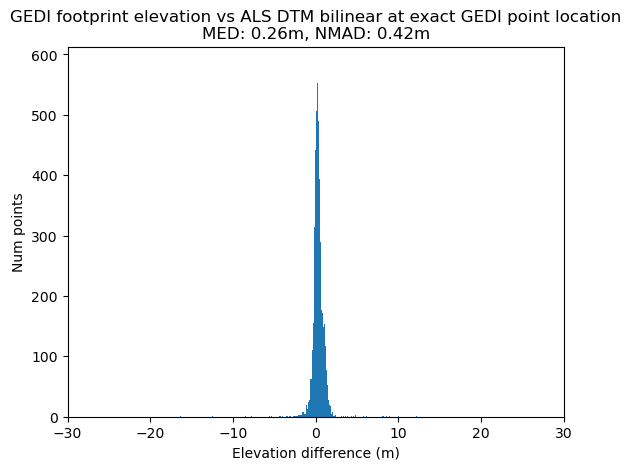

In [48]:
f,ax = plt.subplots()
val_array = output_bilinear_ground['elev_diff'].values
val_array = val_array[~np.isnan(val_array)]
med = np.median(val_array)
nmad = scipy.stats.median_abs_deviation(val_array)*1.4826
ax.hist(val_array,bins=300)
ax.set_xlim(-30,30)
ax.set_xlabel('Elevation difference (m)')
ax.set_ylabel('Num points')
title_stats = f"\nMED: {med:.2f}m, NMAD: {nmad:.2f}m"
ax.set_title('GEDI footprint elevation vs ALS DTM bilinear at exact GEDI point location'+title_stats)

Text(0.5, 1.0, 'GEDI footprint elevation vs ALS DTM median at GEDI footprint\nMED: 0.26m, NMAD: 0.41m')

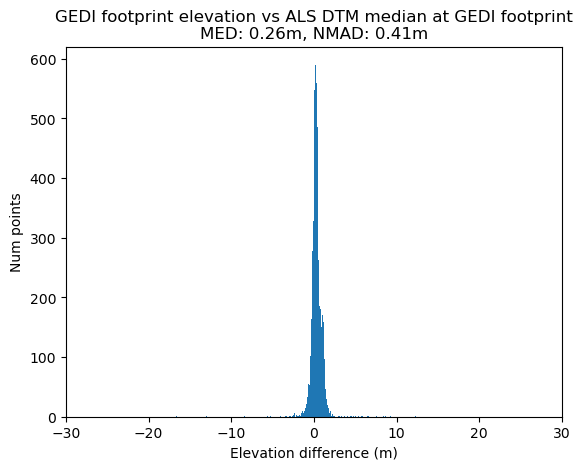

In [49]:
f,ax = plt.subplots()
val_array = median_ground_sample_output['elev_diff'].values
val_array = val_array[~np.isnan(val_array)]
med = np.median(val_array)
nmad = scipy.stats.median_abs_deviation(val_array)*1.4826
ax.hist(val_array,bins=300)
ax.set_xlim(-30,30)
ax.set_xlabel('Elevation difference (m)')
ax.set_ylabel('Num points')
title_stats = f"\nMED: {med:.2f}m, NMAD: {nmad:.2f}m"
ax.set_title('GEDI footprint elevation vs ALS DTM median at GEDI footprint'+title_stats)

In [53]:
median_ground_sample_output

,x,y,dem_elevation,elevation_lm,elev_diff
0,431895.478370,3.489572e+06,1524.194214,1524.536499,0.342285
1,431974.755282,3.489490e+06,1523.680176,1524.044678,0.364502
2,432093.677039,3.489367e+06,1522.645386,1523.012573,0.367188
3,432172.954218,3.489285e+06,1522.094482,1522.455566,0.361084
4,432212.592006,3.489244e+06,1521.851685,1522.211670,0.359985
...,...,...,...,...,...
5806,439283.121250,3.483982e+06,1522.130615,1522.202148,0.071533
5807,439143.374161,3.483280e+06,1534.156494,1534.318970,0.162476
5808,439182.988018,3.483239e+06,1534.583252,1534.625732,0.042480
5809,439222.592289,3.483198e+06,1535.305176,1535.438477,0.133301


AttributeError: 'DataFrame' object has no attribute 'scatter'

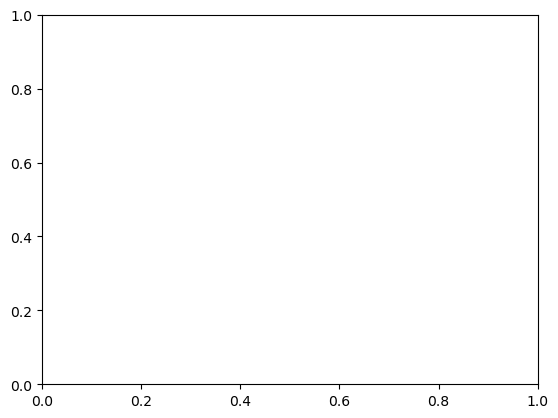

In [54]:
f,ax = plt.subplots()
median_ground_sample_output.scatter(ax=ax,col='elev_diff',cmap='RdBu',clim=(-1,1))